# E-Commerce Sales Insights  
## Data Analysis Project  

---

### Project Overview  

This project performs structured data analysis on an e-commerce transactional dataset.  
The dataset is derived from a relational SQL database developed in a previous project and exported as CSV files to simulate a real-world production environment.

The goal is to transform raw transactional data into meaningful business insights using Python.

---

### Objectives  

- Load structured CSV datasets using Pandas  
- Perform data cleaning and missing value handling  
- Merge relational tables to create an analysis-ready dataset  
- Calculate revenue metrics  
- Perform customer and product-level aggregation  
- Visualize sales performance  
- Generate business insights from analytical results  

---

### Tools & Technologies Used  

- Python  
- Pandas  
- NumPy  
- Matplotlib  
- Jupyter Notebook  

---

### Dataset Structure  

The project uses the following relational tables:

- Customers  
- Products  
- Orders  
- Order_Items  
- Payments  

Each table represents a component of an e-commerce transaction system.

---

### Expected Outcome  

By the end of this analysis, we will:

- Identify high-value customers  
- Determine top-performing products  
- Understand revenue distribution  
- Analyze payment method usage  
- Extract business-level insights from structured data  

## Step 1 - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2 : Dataset Preparation  

The datasets used in this project are derived from the relational 
E-Commerce SQL database developed in Project 3.

Structured CSV files simulate data export from a production system.

The following tables are included:

- Customers  
- Products  
- Orders  
- Order_Items  
- Payments  

## Step 3 - Load CSV Files

In [2]:
customers = pd.read_csv("Customers.csv")
products = pd.read_csv("Products.csv")
orders = pd.read_csv("Orders.csv")
order_items = pd.read_csv("Order_Items.csv")
payments = pd.read_csv("Payments.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


## Step 4 : Data Cleaning & Missing Value Handling  

Before analysis, we check and handle missing values to ensure data accuracy.

In [3]:
# Check Missing Values
print(customers.isnull().sum())
print(products.isnull().sum())
print(orders.isnull().sum())

customer_id    0
name           0
city           1
dtype: int64
product_id      0
product_name    0
price           1
dtype: int64
order_id       0
customer_id    0
status         1
dtype: int64


In [4]:
# Handle Missing Values
customers["city"] = customers["city"].fillna("Unknown")
products["price"] = products["price"].fillna(products["price"].mean())
orders["status"] = orders["status"].fillna("Pending")

print("Missing values handled successfully.")

Missing values handled successfully.


## Step 5 : Data Merging  

Relational tables are merged to create a consolidated dataset for analysis.

In [5]:
# Merge Tables
orders_customers = orders.merge(customers, on="customer_id", how="inner")
order_products = order_items.merge(products, on="product_id", how="inner")

sales_data = order_products.merge(orders_customers, on="order_id", how="inner")

sales_data.head()

,order_id,product_id,quantity,product_name,price,customer_id,status,name,city
0,1,1,1,OnePlus 12,64999.0,1,Delivered,Raghavendra Rao,Bangalore
1,1,3,1,Mysore Silk Saree,7999.0,1,Delivered,Raghavendra Rao,Bangalore
2,2,2,1,Realme Smart TV,38999.0,2,Delivered,Shreya Gowda,Mysuru
3,3,7,1,Data Science Book,699.0,3,Pending,Manjunath Hegde,Unknown
4,4,4,2,Cotton Kurti,1299.0,4,Delivered,Nithya Shetty,Mangaluru


## Step 6 : Revenue Calculation  

Revenue is calculated as:

Revenue = Quantity × Price

In [6]:
# Revenue Calculation
sales_data["revenue"] = sales_data["quantity"] * sales_data["price"]

total_revenue = sales_data["revenue"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 138286.0


## Step 7 : Revenue Analysis  

Identify high-value customers and top-performing products.

In [7]:
# Revenue by Customer
customer_revenue = sales_data.groupby("name")["revenue"].sum().sort_values(ascending=False)
customer_revenue

name
Raghavendra Rao    86497.0
Shreya Gowda       38999.0
Vikram Reddy        4599.0
Nithya Shetty       2598.0
Sneha Patil         1797.0
Darshan Naik        1598.0
Kavitha Rao         1499.0
Manjunath Hegde      699.0
Name: revenue, dtype: float64

In [8]:
# Revenue by Product
product_revenue = sales_data.groupby("product_name")["revenue"].sum().sort_values(ascending=False)
product_revenue

product_name
OnePlus 12              64999.0
Realme Smart TV         38999.0
Mixer Grinder           13499.0
Mysore Silk Saree        7999.0
Cookware Set             4599.0
Cotton Kurti             2598.0
Filter Coffee Powder     1797.0
Yoga Mat                 1598.0
Cricket Bat              1499.0
Data Science Book         699.0
Name: revenue, dtype: float64

## Step 8 : Visualization  

Visualizing revenue trends and payment behavior.

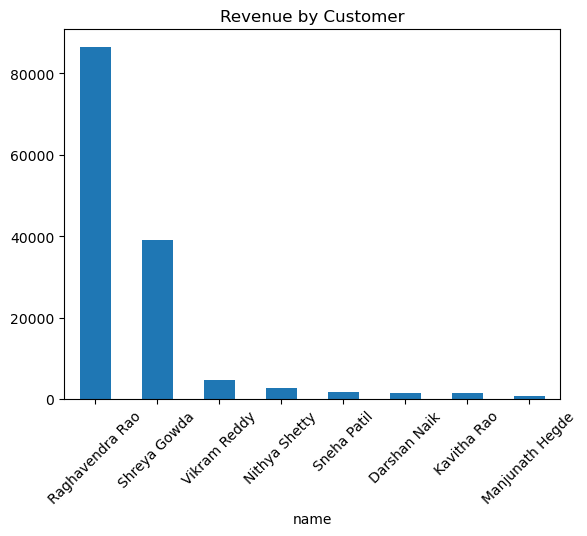

In [9]:
# Bar Chart
plt.figure()
customer_revenue.plot(kind="bar")
plt.title("Revenue by Customer")
plt.xticks(rotation=45)
plt.show()

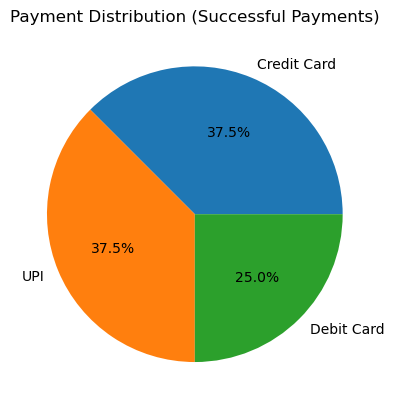

In [10]:
# Payment Analysis + Pie Chart

# Merge sales data with payments table
sales_with_payments = sales_data.merge(payments, on="order_id", how="left")

# Filter only successful payments
successful_payments = sales_with_payments[
    sales_with_payments["payment_status"] == "Success"
]

# Count payment method usage
payment_usage = successful_payments["payment_method"].value_counts()

# Plot pie chart
plt.figure()
payment_usage.plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Distribution (Successful Payments)")
plt.ylabel("")
plt.show()

# Business Insight Summary  

- Total revenue calculated from transactional data.
- High-value customers identified for loyalty strategies.
- Top-performing products recognized.
- Payment preferences analyzed.

This project demonstrates data cleaning, transformation, aggregation,
and visualization for business decision-making.

## Project Completion  

This notebook demonstrates an end-to-end workflow of data loading, 
cleaning, transformation, aggregation, and visualization 
for business insight generation.

The structured approach ensures clarity, reproducibility, 
and real-world applicability.